In [1]:
# import packages and tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

# set plot styles
import matplotlib as mpl
from matplotlib.collections import LineCollection
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['lines.linestyle'] = '-'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = .5

#silence warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load ice data
ice = pd.read_excel("blueIceData.xlsx")
#average duplicate sample at 148.435 meters
#ice = ice.groupby('TopDepth', as_index=False).mean(numeric_only=True)
#remove deepest sample which isn't considered in the original paper
ice = ice.iloc[:-1]
#save a version with only the Long Snapshots to explore
iceLong = ice.loc[ice['SnapshotLong']==1].reset_index(drop=True)

<ErrorbarContainer object of 3 artists>

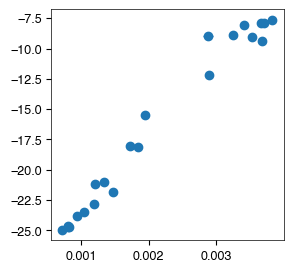

In [ ]:
# now we need to do a correct for respiration-affected samples
# following Marks-Peterson et al let's regress d13C and 1/CO2 for impacted samples
# Select only data with d13C and that are not pristine
dCpres = (~np.isnan(ice.d13C)) & (ice.NotPristine == 1) # & (ice.d13C < -10)#& (ice.SnapshotLong==1)# & (~np.isnan(ice.CO2dC))
# pull out d13C
d13C = ice.d13C[dCpres].to_numpy()
# make an average CO2 column averaging the TWO methods used for measurements.
#CO2avg = iceShort.loc[dCpres,['CO2m','CO2dC']].mean(axis=1).to_numpy()
# OR, only use CO2m
# CO2avg = ice.CO2m[dCpres].to_numpy()
# OR, only use CO2dC
# CO2avg = ice.CO2dC[dCpres].to_numpy()
# OR, use CO2dC where present and CO2m otherwise (CHOICE MADE IN PAPER)
CO2avg = ice.CO2m[dCpres]
CO2avg = np.where(~np.isnan(ice.CO2dC[dCpres]), ice.CO2dC[dCpres], ice.CO2m[dCpres])
CO2methodStd = ice.loc[dCpres,['CO2m','CO2dC']].std(axis=1).to_numpy()
CO2std = ice.CO2mErr[dCpres].to_numpy()
#
# if combining CO2, for the errors use the provided one for CO2m unless the d13C-CO2 error is bigger - then use that.
#CO2std = np.where(CO2std < CO2methodStd, CO2methodStd, CO2std)
# create errors in 1/co2 space
errPos = 1/(CO2avg - CO2std) - 1/CO2avg
errNeg = 1/CO2avg - 1/(CO2avg + CO2std)
errAvg = (errPos + errNeg)/2
# sanity check plot of data
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(1/CO2avg,d13C,xerr=errAvg,marker='o',linestyle="None")

In [4]:
# Let's regress using scipy ODR which is York regression (errors in x and y)
def linear_func(B, x):
    m, c = B
    return m * x + c
xvalues = 1/CO2avg#[d13C < -15])
yvalues = d13C#[d13C < -15]
xerrs = errAvg#[d13C < -15]
yerrs = np.repeat(0.02, len(yvalues))
data = odr.RealData(xvalues, yvalues, xerrs, yerrs)
model = odr.Model(linear_func)
odr_obj = odr.ODR(data, model, beta0=[6000, -29])
out = odr_obj.run()
print(f"Slope: {out.beta[0]:.0f} ± {out.sd_beta[0]:.0f}")
print(f"Intercept: {out.beta[1]:.1f} ± {out.sd_beta[1]:.1f}")

Slope: 6327 ± 280
Intercept: -29.8 ± 0.4


In [5]:
######### RESPIRATION CORRECTION
# based on respiration correction the organic/metabolic end member is -30 +/- 0.5
# here we will monte carlo correct affected data
# first find non-pristine samples that need correction
dCpres = (~np.isnan(ice.d13C)) & (ice.NotPristine == 1) & (ice.SnapshotLong == 1)
# use co2 mean measurements...
# co2m = ice.CO2m[dCpres].to_numpy()
# co2me = ice.CO2mErr[dCpres].to_numpy()
# OR use co2 and co2-d13C average values instead.
# co2m = ice.loc[dCpres,['CO2m','CO2dC']].mean(axis=1).to_numpy()
# co2methodStd = ice.loc[dCpres,['CO2m','CO2dC']].std(axis=1).to_numpy()
# co2me = np.where(co2me < co2methodStd, co2methodStd, co2me)
# OR use d13C-co2 where available otherwise co2 mean
co2m = ice.CO2m[dCpres]
co2m = np.where(~np.isnan(ice.CO2dC[dCpres]), ice.CO2dC[dCpres], ice.CO2m[dCpres])
co2me = ice.CO2mErr[dCpres].to_numpy()

d13cmeas = ice.d13C[dCpres].to_numpy()
d13cmeas = d13cmeas[:,np.newaxis]
# number of simulations
N = 1000
# length of time series
M = len(co2m)
# endmember atmosphere d13C
d13catm = np.random.normal(-6.5, 0.25,size=(M,N))
# endmember organic d13C
d13cOC = np.random.normal(-30, .5,size=(M,N))
d13cOC1 = np.random.normal(-29, .5,size=(M,N))
d13cOC2 = np.random.normal(-31, .5,size=(M,N))
#isotope unmixing
CO2meas = np.random.normal(co2m,co2me,size=(N,M)).T
CO2corr = CO2meas * (d13cOC - d13cmeas) / (d13cOC - d13catm)
CO2corr1 = CO2meas * (d13cOC1 - d13cmeas) / (d13cOC1 - d13catm)
CO2corr2 = CO2meas * (d13cOC2 - d13cmeas) / (d13cOC2 - d13catm)

In [6]:
# load other co2 proxy data for context
# Set the cutoff point in time to find and compile proxy CO2 data (in ka)
timeCut = 3800
# first load 800 ka record of ice core CO2
co2 = pd.read_csv("antarctica2015co2composite-noaa.txt",sep='\t')
co2age = co2['age_gas_calBP'].to_numpy()/1000
co2ppm = co2['co2_ppm'].to_numpy()
# then load boron data - from paleo-co2.org compilation
bdata = pd.read_csv("boron_co2.csv").sort_values(by='age')
# clip to timeCut value
bdataPlio = bdata.loc[bdata['age']<timeCut].reset_index(drop=True)
ageBoron = bdataPlio["age"].to_numpy()
co2Boron = bdataPlio["co2"].to_numpy()

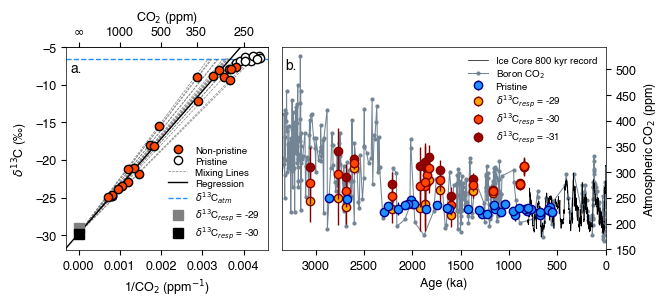

In [10]:
#### FIGURE on respiration correction

ms=6
xlims = (-.0003,0.0046)
ylims = (-32,-5)
step = 0.0001
xtar = np.arange(xlims[0],xlims[1]+step,step)
meanCcorr = np.mean(CO2corr,1)
LineSet = [np.row_stack([(0, out.beta[1]),(1/meanCcorr[i],-6.5)]) for i in range(len(co2m))]
#####
fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1, 1.6]}, figsize=(6.75, 3.15))
axs[0].plot(1/CO2avg,d13C,marker='o',linestyle="None",color="black",
                markeredgecolor="black",markerfacecolor="orangered",markersize=ms,zorder=3,label="Non-pristine")
dCpresA = (~np.isnan(ice.d13C)) & (ice.NotPristine == 0)
co2A = ice.CO2m[dCpresA]
co2A = np.where(~np.isnan(ice.CO2dC[dCpresA]), ice.CO2dC[dCpresA], ice.CO2m[dCpresA])
dCA = ice.d13C[dCpresA]
axs[0].plot(1/co2A,dCA,marker='o',linestyle="None",color="black",
                markeredgecolor="black",markerfacecolor="white",markersize=ms,zorder=2,label="Pristine")
lc = LineCollection(LineSet, linewidths=0.5, colors="gray", linestyles = '--',zorder=1, label="Mixing Lines")
axs[0].add_collection(lc)
axs[0].plot(xtar,xtar*out.beta[0]+out.beta[1],color="black",linewidth=1,zorder=1,label="Regression")
axs[0].plot([xlims[0],xlims[1]],[-6.5,-6.5],color="dodgerblue",linestyle="--",zorder=0,linewidth=1,label="$\delta^{13}$C$_{atm}$")
axs[0].plot(0,-29,marker='s',markersize = ms+1,color="gray",linestyle="None",zorder=4, label="$\delta^{13}$C$_{resp}$ = -29")
axs[0].plot(0,out.beta[1],marker='s',markersize = ms+1,color="black",linestyle="None",zorder=5, label="$\delta^{13}$C$_{resp}$ = -30")
axs[0].set_xlim(xlims)
axs[0].set_ylim(ylims)
axs[0].set_xlabel("1/CO$_2$ (ppm$^{-1}$)")
axs[0].set_ylabel("$\delta^{13}$C (‰)")
axs[0].legend(loc='lower right',frameon=False, fontsize=7, labelspacing=0.2)
axs[0].text(-.0002,-8.3,"a.",fontsize=10)
#
secax = axs[0].secondary_xaxis('top', functions=(lambda x: 1/x, lambda x: 1/x))
secax.set_xlabel("CO$_2$ (ppm)")
secax.set_xticks([float('inf'), 1000, 500, 350, 250], labels=['$\infty$','1000', '500', '350', '250'])
############## SECOND PANEL CO2
axs[1].plot(co2age,co2ppm,color="black",linewidth=0.5,label="Ice Core 800 kyr record",zorder=3)
axs[1].plot(ageBoron,co2Boron,color="xkcd:steel",linewidth=.75,marker='o',markersize=2, label="Boron CO$_2$",zorder=2)
prist = (ice.NotPristine == 0) & (ice.SnapshotLong == 1)
axs[1].errorbar(ice.Age[prist],ice.CO2m[prist],yerr=ice.CO2mErr[prist]*2,markerfacecolor="dodgerblue",linestyle="None",
        markeredgecolor="darkblue",marker='o',markersize=ms, color="darkblue",label="Pristine",zorder=18)
axs[1].errorbar(ice.Age[dCpres],np.mean(CO2corr1,1),yerr=np.std(CO2corr1,1)*2,color="xkcd:dark red",marker='o',linestyle='None',
        markeredgecolor="xkcd:dark red",markerfacecolor="orange",markersize=ms,label="$\delta^{13}$C$_{resp}$ = -29",zorder=13)
axs[1].errorbar(ice.Age[dCpres],np.mean(CO2corr,1),yerr=np.std(CO2corr,1)*2,color="xkcd:dark red",marker='o',linestyle='None',
        markeredgecolor="xkcd:dark red",markerfacecolor="orangered",markersize=ms,label="$\delta^{13}$C$_{resp}$ = -30",zorder=14)
axs[1].errorbar(ice.Age[dCpres],np.mean(CO2corr2,1),yerr=np.std(CO2corr2,1)*2,color="xkcd:dark red",marker='o',linestyle='None',
        markeredgecolor="xkcd:dark red",markerfacecolor="xkcd:deep red",markersize=ms,label="$\delta^{13}$C$_{resp}$ = -31",zorder=12)
axs[1].set_xlabel("Age (ka)")
axs[1].set_ylabel("Atmospheric CO$_2$ (ppm)")
axs[1].legend(loc='upper right',frameon=False, fontsize=7, labelspacing=0.2)
axs[1].text(3320,500,"b.",fontsize=10)
#
axs[1].set_xlim(0,3350)
axs[1].yaxis.tick_right()
axs[1].yaxis.set_label_position("right")
axs[1].invert_xaxis()

fig.tight_layout()
fig.savefig("RespirationCorrection.pdf", bbox_inches="tight")